## Topic 4
### Logistic Regression and it's Evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv("Datasets/spam_detection_dataset.csv")
df.head(10)

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1
5,2,197,0,0.466201,0,0
6,0,166,1,1.000000,0,0
7,0,113,0,0.600813,0,0
8,1,169,0,0.753108,0,0
9,1,150,1,1.000000,0,0


In [2]:
# Exploring the dataset
df.shape

(20000, 6)

In [3]:
df.columns

Index(['num_links', 'num_words', 'has_offer', 'sender_score', 'all_caps',
       'is_spam'],
      dtype='object')

In [4]:
df.describe()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,1.497300,109.506150,0.302750,0.694248,0.097800,0.09175
std,1.220478,51.969579,0.459459,0.188312,0.297051,0.28868
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,64.000000,0.000000,0.567073,0.000000,0.00000
50%,1.000000,110.000000,0.000000,0.699740,0.000000,0.00000
75%,2.000000,154.000000,1.000000,0.834083,0.000000,0.00000
max,9.000000,199.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_links     20000 non-null  int64  
 1   num_words     20000 non-null  int64  
 2   has_offer     20000 non-null  int64  
 3   sender_score  20000 non-null  float64
 4   all_caps      20000 non-null  int64  
 5   is_spam       20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [6]:
df.isnull().sum() # No missing values

num_links       0
num_words       0
has_offer       0
sender_score    0
all_caps        0
is_spam         0
dtype: int64

In [7]:
df.skew()

num_links       0.829747
num_words      -0.009390
has_offer       0.858704
sender_score   -0.279300
all_caps        2.708219
is_spam         2.828675
dtype: float64

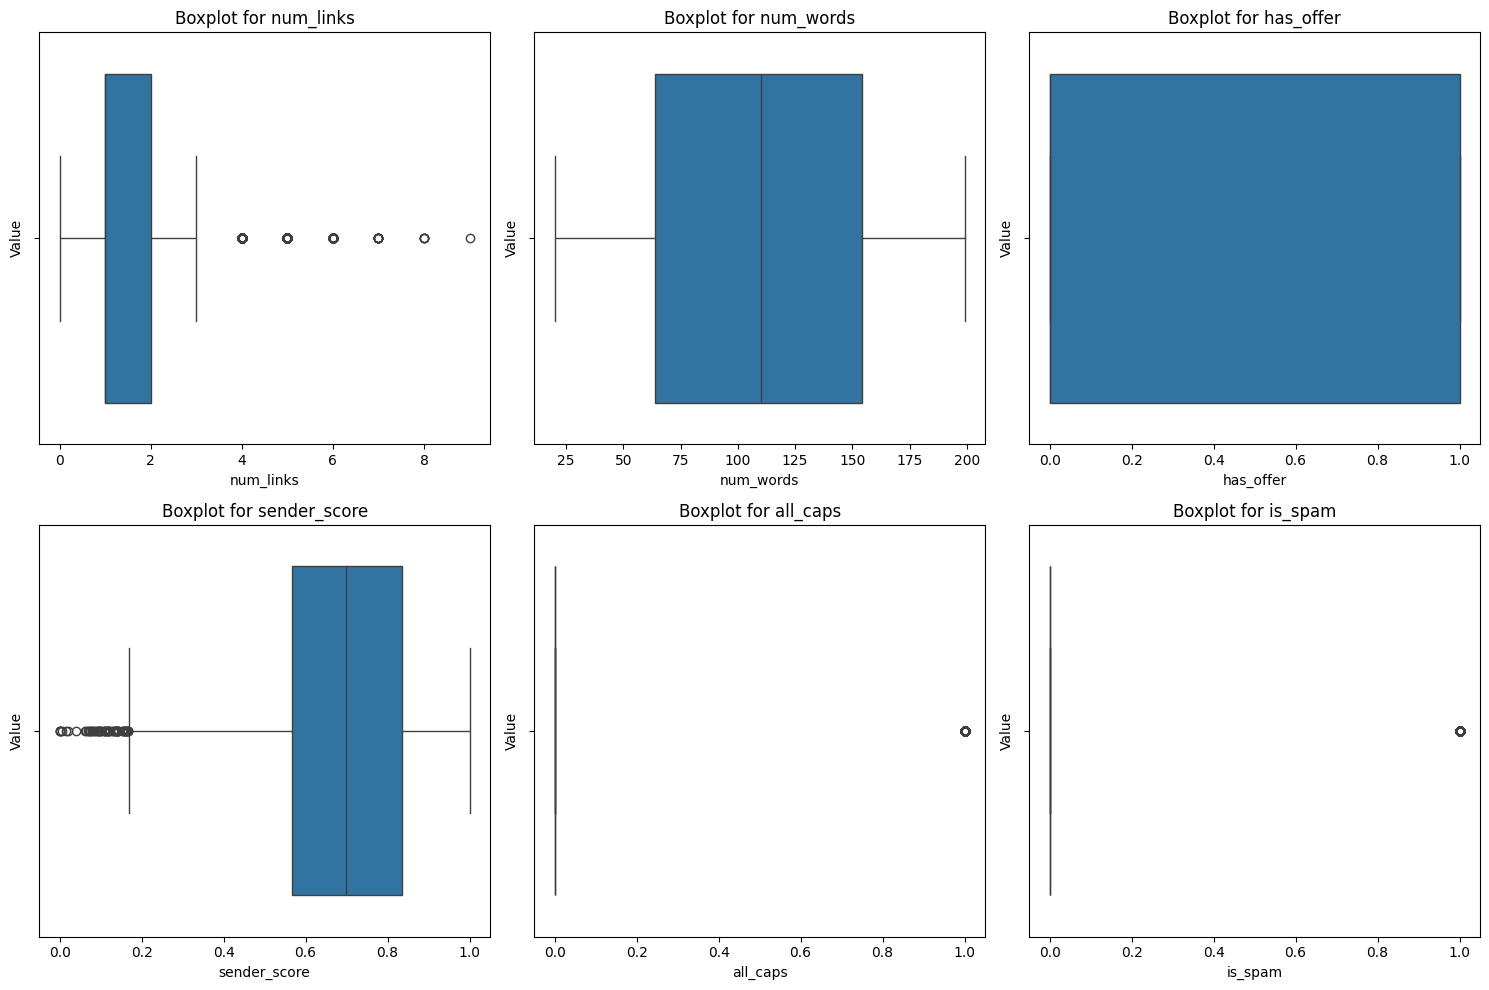

In [8]:
numeric_cols = list(df.columns) # For Boxplots

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=col, ax=axs[i])
    axs[i].set(title=f"Boxplot for {col}", xlabel=col, ylabel="Value")

plt.tight_layout()
plt.show()

In [9]:
lower = df['sender_score'].quantile(0.01)
upper = df['sender_score'].quantile(0.99)

df['sender_score_capped'] = df['sender_score'].clip(lower, upper)

In [10]:
df = df.drop("sender_score", axis=1)

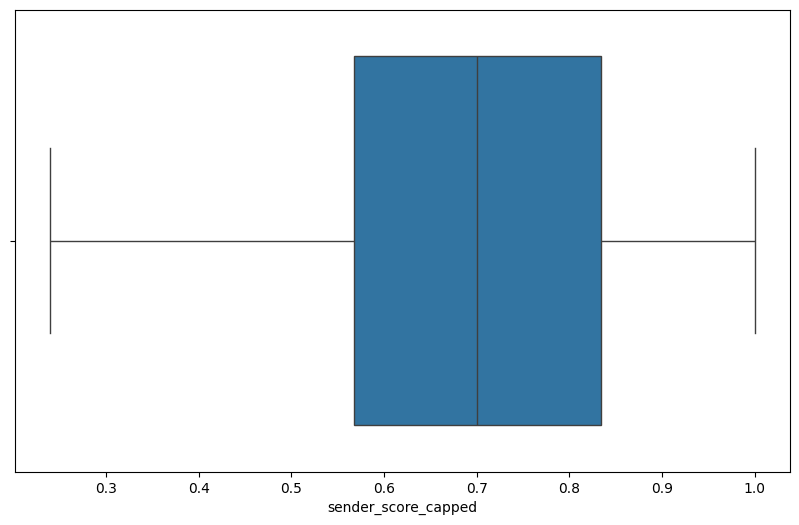

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=df, x="sender_score_capped", ax=ax);

In [12]:
df.head()

,num_links,num_words,has_offer,all_caps,is_spam,sender_score_capped
0,3,98,1,0,0,0.718607
1,0,170,0,1,0,0.698901
2,0,38,0,0,0,0.620466
3,0,116,0,0,0,0.701755
4,3,89,1,1,1,0.583621


In [13]:
df.nunique()

num_links                 10
num_words                180
has_offer                  2
all_caps                   2
is_spam                    2
sender_score_capped    18451
dtype: int64

In [14]:
# Check class imbalance
df["is_spam"].value_counts(normalize=True) # There is imbalance ~90% not spam, ~9% spam

is_spam
0    0.90825
1    0.09175
Name: proportion, dtype: float64

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

scaler = StandardScaler()
to_scale = ['num_links', 'num_words', 'sender_score_capped']

X = df.drop("is_spam", axis=1)
y = df["is_spam"]

# Stratify - Distribution of y in split sets is same as original data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

X_train_scaled_part = scaler.fit_transform(X_train[to_scale])  # Scale and Learn params (mean, std)
X_val_scaled_part = scaler.transform(X_val[to_scale])          # Scale using training's learned stats

# Replace scaled columns back into original dataframes
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

X_train_scaled[to_scale] = X_train_scaled_part
X_val_scaled[to_scale] = X_val_scaled_part

In [16]:
# Now to apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {Counter(y_train)}")
print(f"After SMOTE: {Counter(y_train_smote)}")
# Dataset is balanced now

Before SMOTE: Counter({0: 13624, 1: 1376})
After SMOTE: Counter({0: 13624, 1: 13624})


c:\Users\prash\anaconda3\envs\gpt2_finetune\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [17]:
# Logistic Regression Class
class LogisticRegression:
    def __init__(self, learning_rate=0.001, n_iters=1000, reg_lambda=0.01):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.reg_lambda = reg_lambda
        self.weights = None
        self.bias = None
        self.losses = []
         
    # Sigmoid method
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    # Regularized loss function (Binary Cross-Entropy + L2)
    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-9
        bce = -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))
        reg_term = (self.reg_lambda / 2) * np.sum(self.weights ** 2)
        return bce + reg_term

    def feed_forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            A = self.feed_forward(X)
            loss = self.compute_loss(y, A)
            self.losses.append(loss)

            dz = A - y
            dw = (1 / n_samples) * (np.dot(X.T, dz) + self.reg_lambda * self.weights)  # Add regularization gradient
            db = (1 / n_samples) * np.sum(dz)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        y_probs = self._sigmoid(np.dot(X, self.weights) + self.bias)
        return np.array([1 if p > 0.5 else 0 for p in y_probs])

In [18]:
def accuracy_score_scr(y_true, y_pred):
    correct = (y_true == y_pred).sum()
    total = len(y_true)
    return correct / total

def precision_score_scr(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    if tp + fp == 0:
        return 0
    return tp / (tp + fp)

def recall_score_scr(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    if tp + fn == 0:
        return 0
    return tp / (tp + fn)

def f1_score_scr(y_true, y_pred):
    prec = precision_score_scr(y_true, y_pred)
    rec = recall_score_scr(y_true, y_pred)
    if prec + rec == 0:
        return 0
    return 2 * (prec * rec) / (prec + rec)


In [19]:
# Initialize and train model
model = LogisticRegression(learning_rate=0.01, n_iters=1000, reg_lambda=0.01)
model.fit(X_train_smote, y_train_smote)

# Predict on validation set
y_val_pred = model.predict(X_val_scaled)

# Evaluation metrics
print("Accuracy:", round(accuracy_score_scr(y_val, y_val_pred), 3))
print("Precision:", round(precision_score_scr(y_val, y_val_pred), 3))
print("Recall:", round(recall_score_scr(y_val, y_val_pred), 3))
print("F1 Score:", round(f1_score_scr(y_val, y_val_pred), 3))

Accuracy: 0.733
Precision: 0.239
Recall: 0.878
F1 Score: 0.376


[[ 403 1280]
 [  56 3261]]


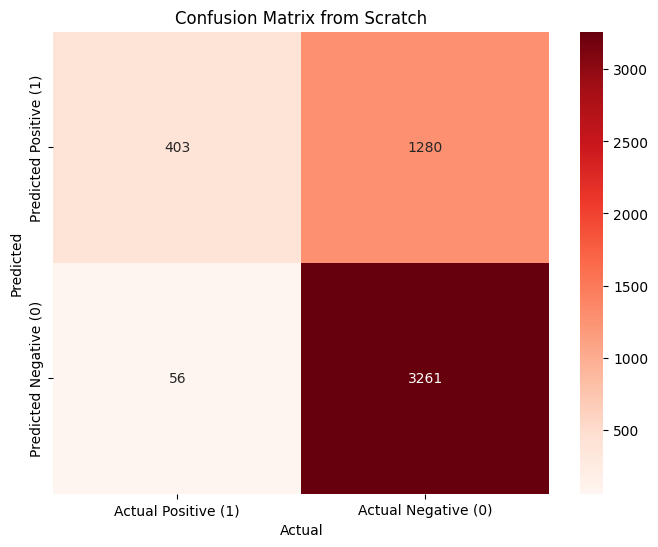

In [20]:
def plot_confusion_matrix_scr(y_true, y_pred):
    # Calculate confusion matrix values
    title="Confusion Matrix from Scratch"

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    # Create matrix in standard format
    cm = np.array([[tp, fp],
                   [fn, tn]])
    
    print(cm)
    
    # Plot with seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=['Actual Positive (1)', 'Actual Negative (0)'],
                yticklabels=['Predicted Positive (1)', 'Predicted Negative (0)'])
    
    plt.title(title)
    plt.ylabel('Predicted')
    plt.xlabel('Actual')
    plt.savefig("Images/confusion_scratch.png")
    plt.show()

plot_confusion_matrix_scr(y_val, y_val_pred)

In [21]:
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialize and train sklearn logistic regression model
sk_model = SklearnLogisticRegression(max_iter=1000, random_state=42)
sk_model.fit(X_train_smote, y_train_smote)

# Predict on validation set
y_val_pred_sk = sk_model.predict(X_val_scaled)

# Generate and print classification report
print("Classification Report - sklearn Logistic Regression:")
print(classification_report(y_val, y_val_pred_sk))


Classification Report - sklearn Logistic Regression:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      4541
           1       0.38      0.86      0.53       459

    accuracy                           0.86      5000
   macro avg       0.68      0.86      0.72      5000
weighted avg       0.93      0.86      0.88      5000



In [22]:
# Compute metrics separately
print("Sklearn Logistic Regression Metrics:")
print("Accuracy:", round(accuracy_score(y_val, y_val_pred_sk), 3))
print("Precision:", round(precision_score(y_val, y_val_pred_sk), 3))
print("Recall:", round(recall_score(y_val, y_val_pred_sk), 3))
print("F1 Score:", round(f1_score(y_val, y_val_pred_sk), 3))

Sklearn Logistic Regression Metrics:
Accuracy: 0.859
Precision: 0.38
Recall: 0.858
F1 Score: 0.527


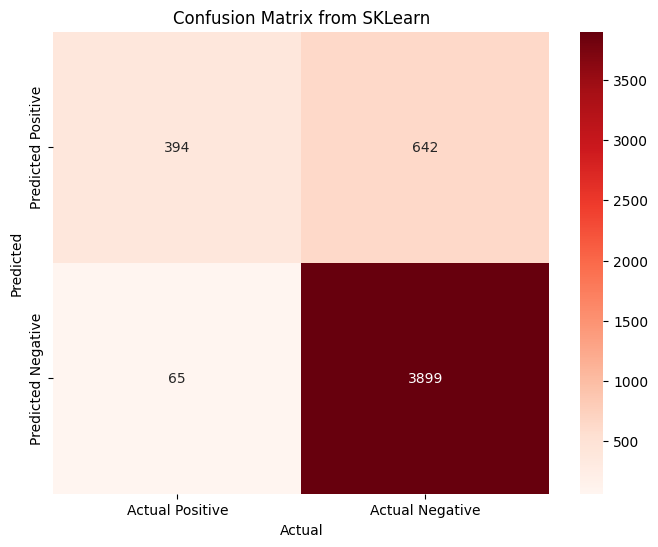

In [23]:
def plot_confusion_matrix_sklearn(y_true, y_pred):
    cm_sklearn = confusion_matrix(y_true, y_pred)

    title = "Confusion Matrix from SKLearn"        
    tn, fp, fn, tp = cm_sklearn.ravel() # Ravel to Flatten
    cm = np.array([[tp, fp],
                   [fn, tn]])
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Actual Positive', 'Actual Negative'],
                yticklabels=['Predicted Positive', 'Predicted Negative'])
    plt.title(title)
    plt.ylabel('Predicted')
    plt.xlabel('Actual')
    plt.savefig("Images/confusion_sklearn.png")
    plt.show()

plot_confusion_matrix_sklearn(y_val, y_val_pred_sk)

In [24]:
# Comparison 
metrics_scratch = {
    "Accuracy": round(accuracy_score_scr(y_val, y_val_pred), 3),
    "Precision": round(precision_score_scr(y_val, y_val_pred), 3),
    "Recall": round(recall_score_scr(y_val, y_val_pred), 3),
    "F1 Score": round(f1_score_scr(y_val, y_val_pred), 3)
}

metrics_sklearn = {
    "Accuracy": round(accuracy_score(y_val, y_val_pred_sk), 3),
    "Precision": round(precision_score(y_val, y_val_pred_sk), 3),
    "Recall": round(recall_score(y_val, y_val_pred_sk), 3),
    "F1 Score": round(f1_score(y_val, y_val_pred_sk), 3)
}

df_metrics = pd.DataFrame({
    "From Scratch": metrics_scratch,
    "Sklearn": metrics_sklearn
})

print(df_metrics)

           From Scratch  Sklearn
Accuracy          0.733    0.859
Precision         0.239    0.380
Recall            0.878    0.858
F1 Score          0.376    0.527
